In [1]:
import xarray as xr
SST_PATH = r"D:\\NITD\\2nd Sem\\Computational Simulation Lab\\ERA5_SST_sst_K_monmean_7924_1.nc"
ds = xr.open_dataset(SST_PATH)
print(ds)
var = ds["sst"]
print(var.attrs)

<xarray.Dataset> Size: 143MB
Dimensions:    (time: 552, bnds: 2, lon: 360, lat: 180)
Coordinates:
  * time       (time) datetime64[ns] 4kB 1979-01-16T10:00:00 ... 2024-12-16T1...
  * lon        (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat        (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) datetime64[ns] 9kB ...
    sst        (time, lat, lon) float32 143MB ...
Attributes:
    CDI:          Climate Data Interface version 2.0.4 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Sat Jun 21 21:59:38 2025: cdo -remapbil,ORAS5_SIT_iicethic_...
    frequency:    mon
    CDO:          Climate Data Operators version 2.0.4 (https://mpimet.mpg.de...
{'long_name': 'Sea surface temperature', 'units': 'K', 'cell_methods': 'time: mean'}


                            AutoReg Model Results                             
Dep. Variable:                    sst   No. Observations:                  441
Model:                    AutoReg(12)   Log Likelihood                 725.640
Method:               Conditional MLE   S.D. of innovations              0.045
Date:                Wed, 21 Jan 2026   AIC                          -1423.279
Time:                        12:50:15   BIC                          -1366.419
Sample:                            12   HQIC                         -1400.825
                                  441                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.7727      6.110      1.108      0.268      -5.202      18.748
sst.L1         1.2168      0.046     26.202      0.000       1.126       1.308
sst.L2        -0.5327      0.068     -7.802      0.0

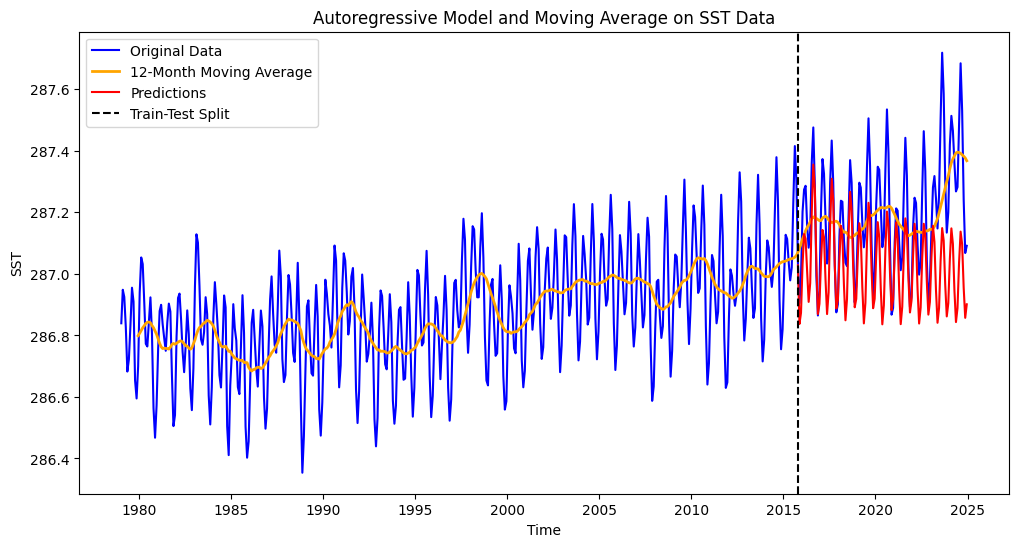

In [2]:
# Plot the time series using Auto Regressive model and Moving Average on SST Data
import xarray as xr
import numpy as np
import pandas as pd
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Step 2: Preprocess the data
# Assuming the dataset has a 'time' dimension and 'sst' variable
sst_data = ds['sst']  # Replace 'sst' with the actual variable name in your file
sst_series = sst_data.mean(dim=['lat', 'lon']).values  # Take spatial average (if applicable)
time = pd.to_datetime(ds['time'].values)

# Create a DataFrame for time series analysis
df = pd.DataFrame({'time': time, 'sst': sst_series}).dropna()

# Step 3: Compute Moving Average
window_size = 12  # Moving average window (e.g., 12 months for annual smoothing)
df['moving_average'] = df['sst'].rolling(window=window_size).mean()

# Step 4: Split the data
train_size = int(len(df) * 0.8)
train, test = df['sst'][:train_size], df['sst'][train_size:]

# Step 5: Fit the autoregressive model
lag = 12  # Number of lags
ar_model = AutoReg(train, lags=lag)
ar_model_fit = ar_model.fit()

# Print model summary
print(ar_model_fit.summary())

# Step 6: Make predictions
predictions = ar_model_fit.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)

# Step 7: Evaluate the model
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f"Root Mean Square Error: {rmse}")

# Step 8: Plot the results
plt.figure(figsize=(12, 6))

# Plot original SST data
plt.plot(df['time'], df['sst'], label="Original Data", color="blue")

# Plot moving average
plt.plot(df['time'], df['moving_average'], label=f"{window_size}-Month Moving Average", color="orange", linewidth=2)

# Plot predictions
plt.plot(df['time'][train_size:], predictions, label="Predictions", color="red")

# Add train-test split marker
plt.axvline(df['time'].iloc[train_size], color='black', linestyle='--', label="Train-Test Split")

# Add labels, legend, and title
plt.xlabel("Time")
plt.ylabel("SST")
plt.legend()
plt.title("Autoregressive Model and Moving Average on SST Data")
plt.show()

                            AutoReg Model Results                             
Dep. Variable:                    sst   No. Observations:                  441
Model:                    AutoReg(12)   Log Likelihood                 859.207
Method:               Conditional MLE   S.D. of innovations              0.033
Date:                Mon, 04 May 2026   AIC                          -1690.415
Time:                        16:13:58   BIC                          -1633.555
Sample:                            12   HQIC                         -1667.960
                                  441                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0102      0.008      1.244      0.214      -0.006       0.026
sst.L1         1.2168      0.046     26.202      0.000       1.126       1.308
sst.L2        -0.5327      0.068     -7.802      0.0

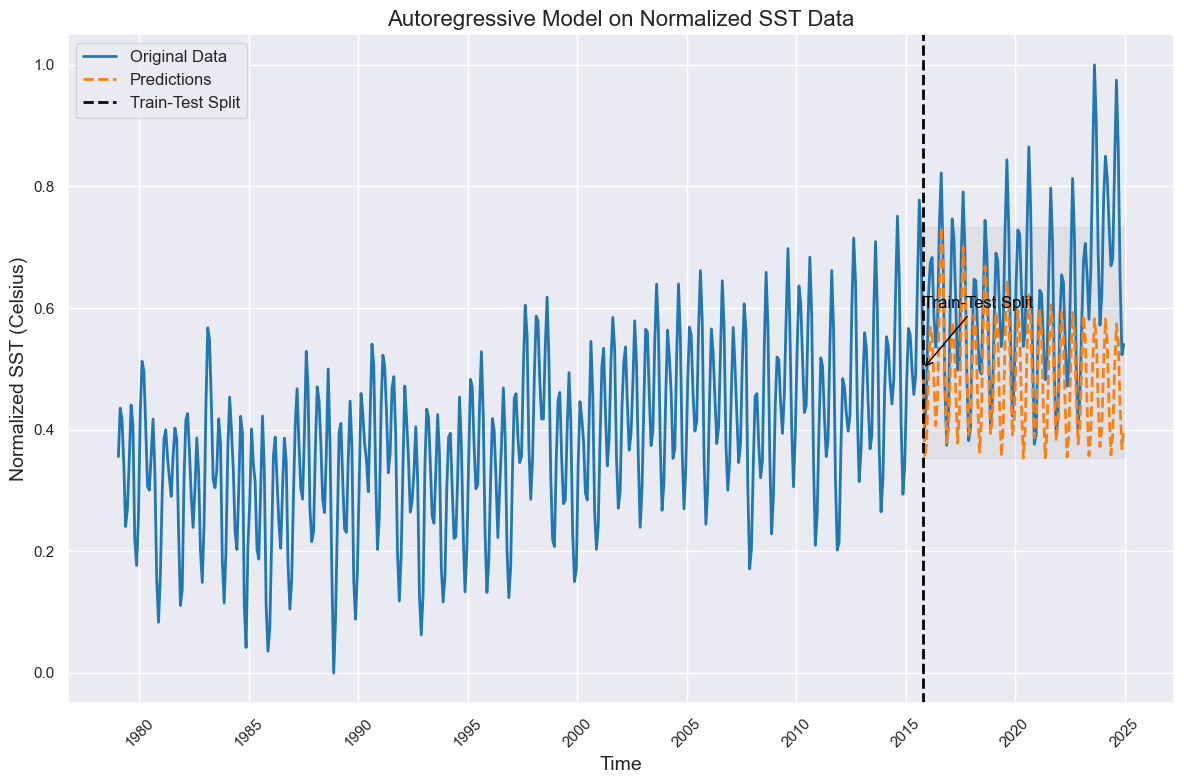

In [1]:
# Import necessary libraries
 # install seaborn library in colab
import seaborn as sns
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import pandas as pd
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# Step 1: Load SST data
sst_file_path = r"D:\\NITD\\2nd Sem\\Computational Simulation Lab\\ERA5_SST_sst_K_monmean_7924_1.nc"
data = xr.open_dataset(sst_file_path)

# Step 2: Preprocess the data
# Assuming the dataset has a 'time' dimension and 'sst' variable
sst_data = data['sst']  # Replace 'sst' with the actual variable name in your file
sst_series = sst_data.mean(dim=['lat', 'lon']).values  # Take spatial average (if applicable)
time = pd.to_datetime(data['time'].values)

# Convert Kelvin to Celsius
sst_series_celsius = sst_series - 273.15  # SST in Celsius

# Normalize the SST data
scaler = MinMaxScaler(feature_range=(0, 1))
sst_series_normalized = scaler.fit_transform(sst_series_celsius.reshape(-1, 1)).flatten()

# Create a DataFrame for time series analysis
df = pd.DataFrame({'time': time, 'sst': sst_series_normalized}).dropna()

# Step 3: Split the data
train_size = int(len(df) * 0.8)
train, test = df['sst'][:train_size], df['sst'][train_size:]

# Step 4: Fit the autoregressive model
lag = 12  # Number of lags (you can tune this hyperparameter)
ar_model = AutoReg(train, lags=lag)
ar_model_fit = ar_model.fit()

# Print model summary
print(ar_model_fit.summary())

# Step 5: Make predictions
predictions = ar_model_fit.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)

# Step 6: Evaluate the model
rmse = np.sqrt(mean_squared_error(test, predictions))
print(f"Root Mean Square Error: {rmse}")

# Step 7: Plot the results
sns.set_theme(style="darkgrid") # Use Seaborn's set_theme to apply the darkgrid style
plt.figure(figsize=(12, 8))
plt.plot(df['time'], df['sst'], label="Original Data", color='tab:blue', linewidth=2)  # Original data in blue
plt.plot(df['time'][train_size:], predictions, label="Predictions", color='tab:orange', linewidth=2, linestyle='--')  # Predictions in orange (dashed line)
plt.axvline(df['time'].iloc[train_size], color='black', linestyle='--', label="Train-Test Split", linewidth=2)  # Vertical line for train-test split
plt.fill_between(df['time'][train_size:], min(predictions), max(predictions), color='gray', alpha=0.1)  # Shading area between predictions

# Add annotations for visual clarity
plt.annotate("Train-Test Split", xy=(df['time'].iloc[train_size], 0.5), xytext=(df['time'].iloc[train_size], 0.6),
             arrowprops=dict(arrowstyle="->", color="black"), fontsize=12, color="black")

# Add labels and title
plt.xlabel("Time", fontsize=14)
plt.ylabel("Normalized SST (Celsius)", fontsize=14)
plt.title("Autoregressive Model on Normalized SST Data", fontsize=16)
plt.legend(fontsize=12)

# Improve the x-axis tick labels for better readability
plt.xticks(rotation=45)

# Show plot
plt.tight_layout()
plt.show()